# KMeans 개선안 3: HOG 특징 사용

원본 픽셀값 대신 이미지의 윤곽선과 방향 정보를 요약하는 HOG(Histogram of Oriented Gradients) 특징을 추출해 KMeans에 사용합니다.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)


In [2]:
import numpy as np

fruits = np.load('fruits_300.npy')

In [3]:
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler

def extract_hog_features(images):
    return np.array([
        hog(
            image,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True,
        )
        for image in images
    ])

hog_features = extract_hog_features(fruits)
hog_features_scaled = StandardScaler().fit_transform(hog_features)

print('HOG feature shape:', hog_features_scaled.shape)


HOG feature shape: (300, 4356)


In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, n_init=20, random_state=42)
km.fit(hog_features_scaled)

print(km.labels_)
print(np.unique(km.labels_, return_counts=True))


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2]
(array([0, 1, 2], dtype=int32), array([100, 100, 100]))


In [5]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    n = len(arr)    # n은 샘플 개수입니다
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나눈 올림값을 구합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개이면 열의 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n 개수만큼 이미지를 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()


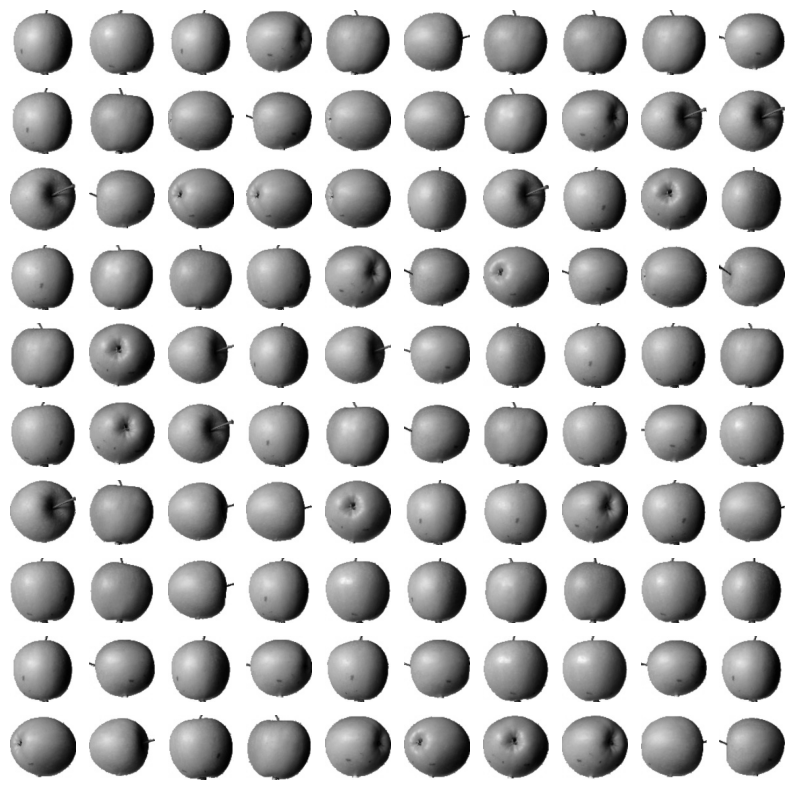

In [6]:
draw_fruits(fruits[km.labels_==0])

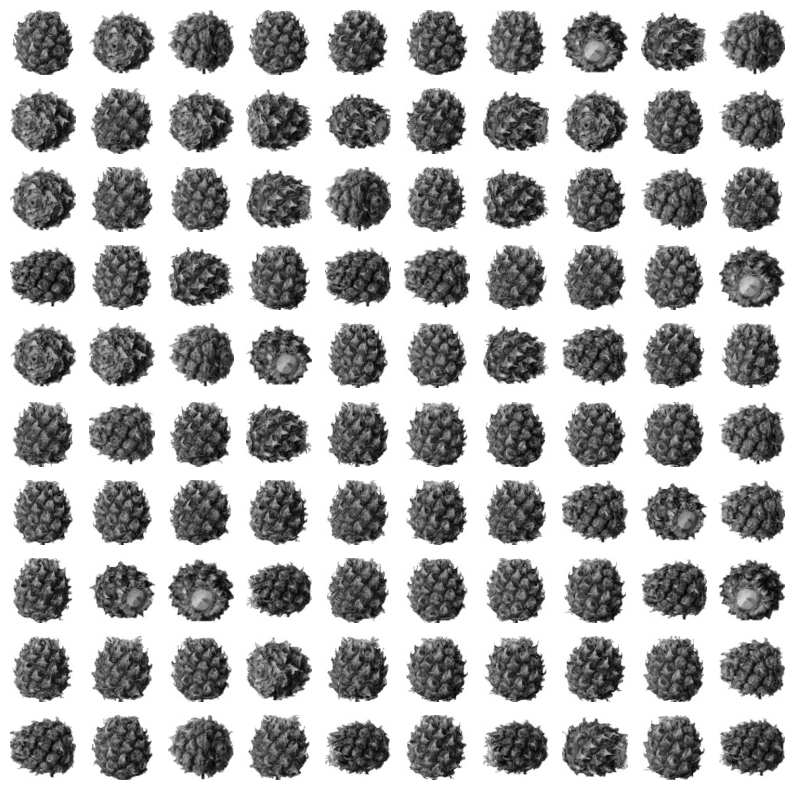

In [7]:
draw_fruits(fruits[km.labels_==1])

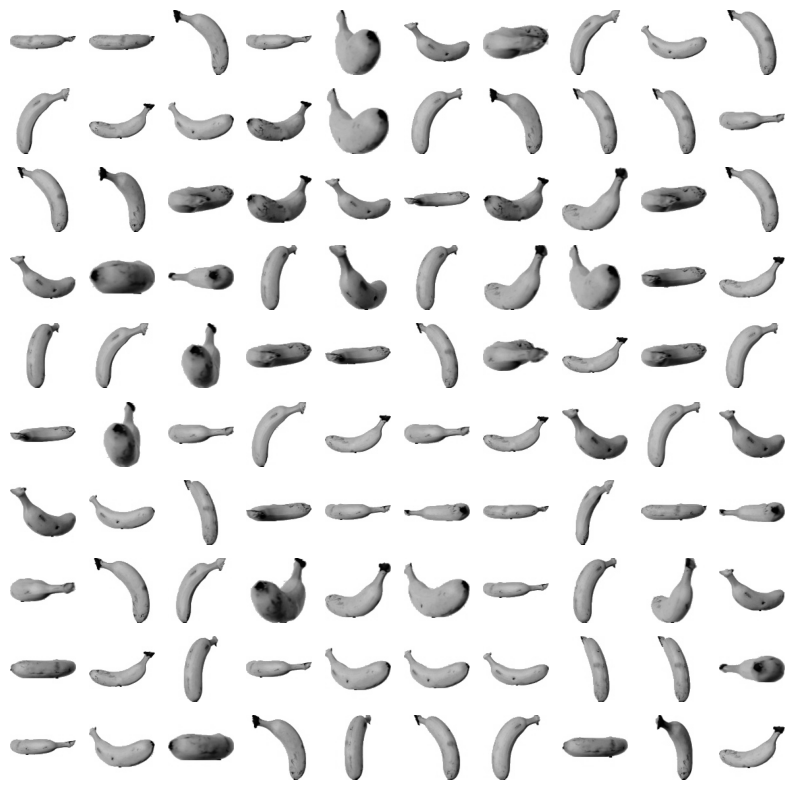

In [8]:
draw_fruits(fruits[km.labels_==2])

## 클러스터 분석


In [9]:
print(km.transform(hog_features_scaled[100:101]))

[[77.63376134 48.27976354 77.11887739]]


In [10]:
print(km.predict(hog_features_scaled[100:101]))

[1]


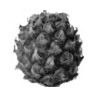

In [11]:
draw_fruits(fruits[100:101])

In [12]:
print(km.n_iter_)

8


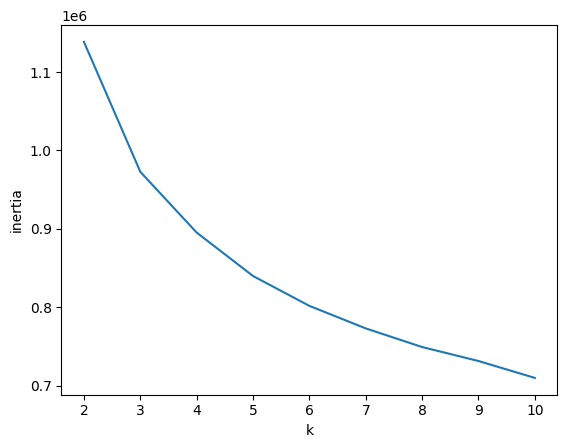

In [13]:
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(hog_features_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()